In [1]:
import cv2

video_path = "14498462_540_960_30fps.mp4"
video = cv2.VideoCapture(video_path)



In [2]:
import os

os.makedirs("frames", exist_ok=True) # frames folder yaratlyabdi

frame_id = 0

while True:
    ret, frame = video.read()
    
    if not ret: # videoni toliq oqib bolgandan song while loopdan chiqadi
        break

    if frame_id % 30 == 0: 
        cv2.imwrite(f"frames/frame_{frame_id:06d}.jpg", frame) # har 30-kadrni saqlayabdi

    frame_id += 1 # har bir framening idsi

print("Frame_id: ", frame_id)

Frame_id:  496


In [6]:
frames = sorted(os.listdir("frames"))
frames

sequence_length = 5
sequences = []

for i in range(len(frames) - sequence_length + 1):
    seq = frames[i:i+sequence_length]
    sequences.append(seq)

In [7]:
frames

['frame_000000.jpg',
 'frame_000030.jpg',
 'frame_000060.jpg',
 'frame_000090.jpg',
 'frame_000120.jpg',
 'frame_000150.jpg',
 'frame_000180.jpg',
 'frame_000210.jpg',
 'frame_000240.jpg',
 'frame_000270.jpg',
 'frame_000300.jpg',
 'frame_000330.jpg',
 'frame_000360.jpg',
 'frame_000390.jpg',
 'frame_000420.jpg',
 'frame_000450.jpg',
 'frame_000480.jpg']

In [13]:
len(sequences)

13

In [12]:
len(sequences[len(sequences) - 1])

5

In [11]:
total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_seconds = total_frames / fps if fps else 0

print("total_frames:", total_frames)
print("fps:", fps)
print("width:", width)
print("height:", height)
print("duration_seconds:", round(duration_seconds, 2))

total_frames: 496
fps: 30.0
width: 540
height: 960
duration_seconds: 16.53


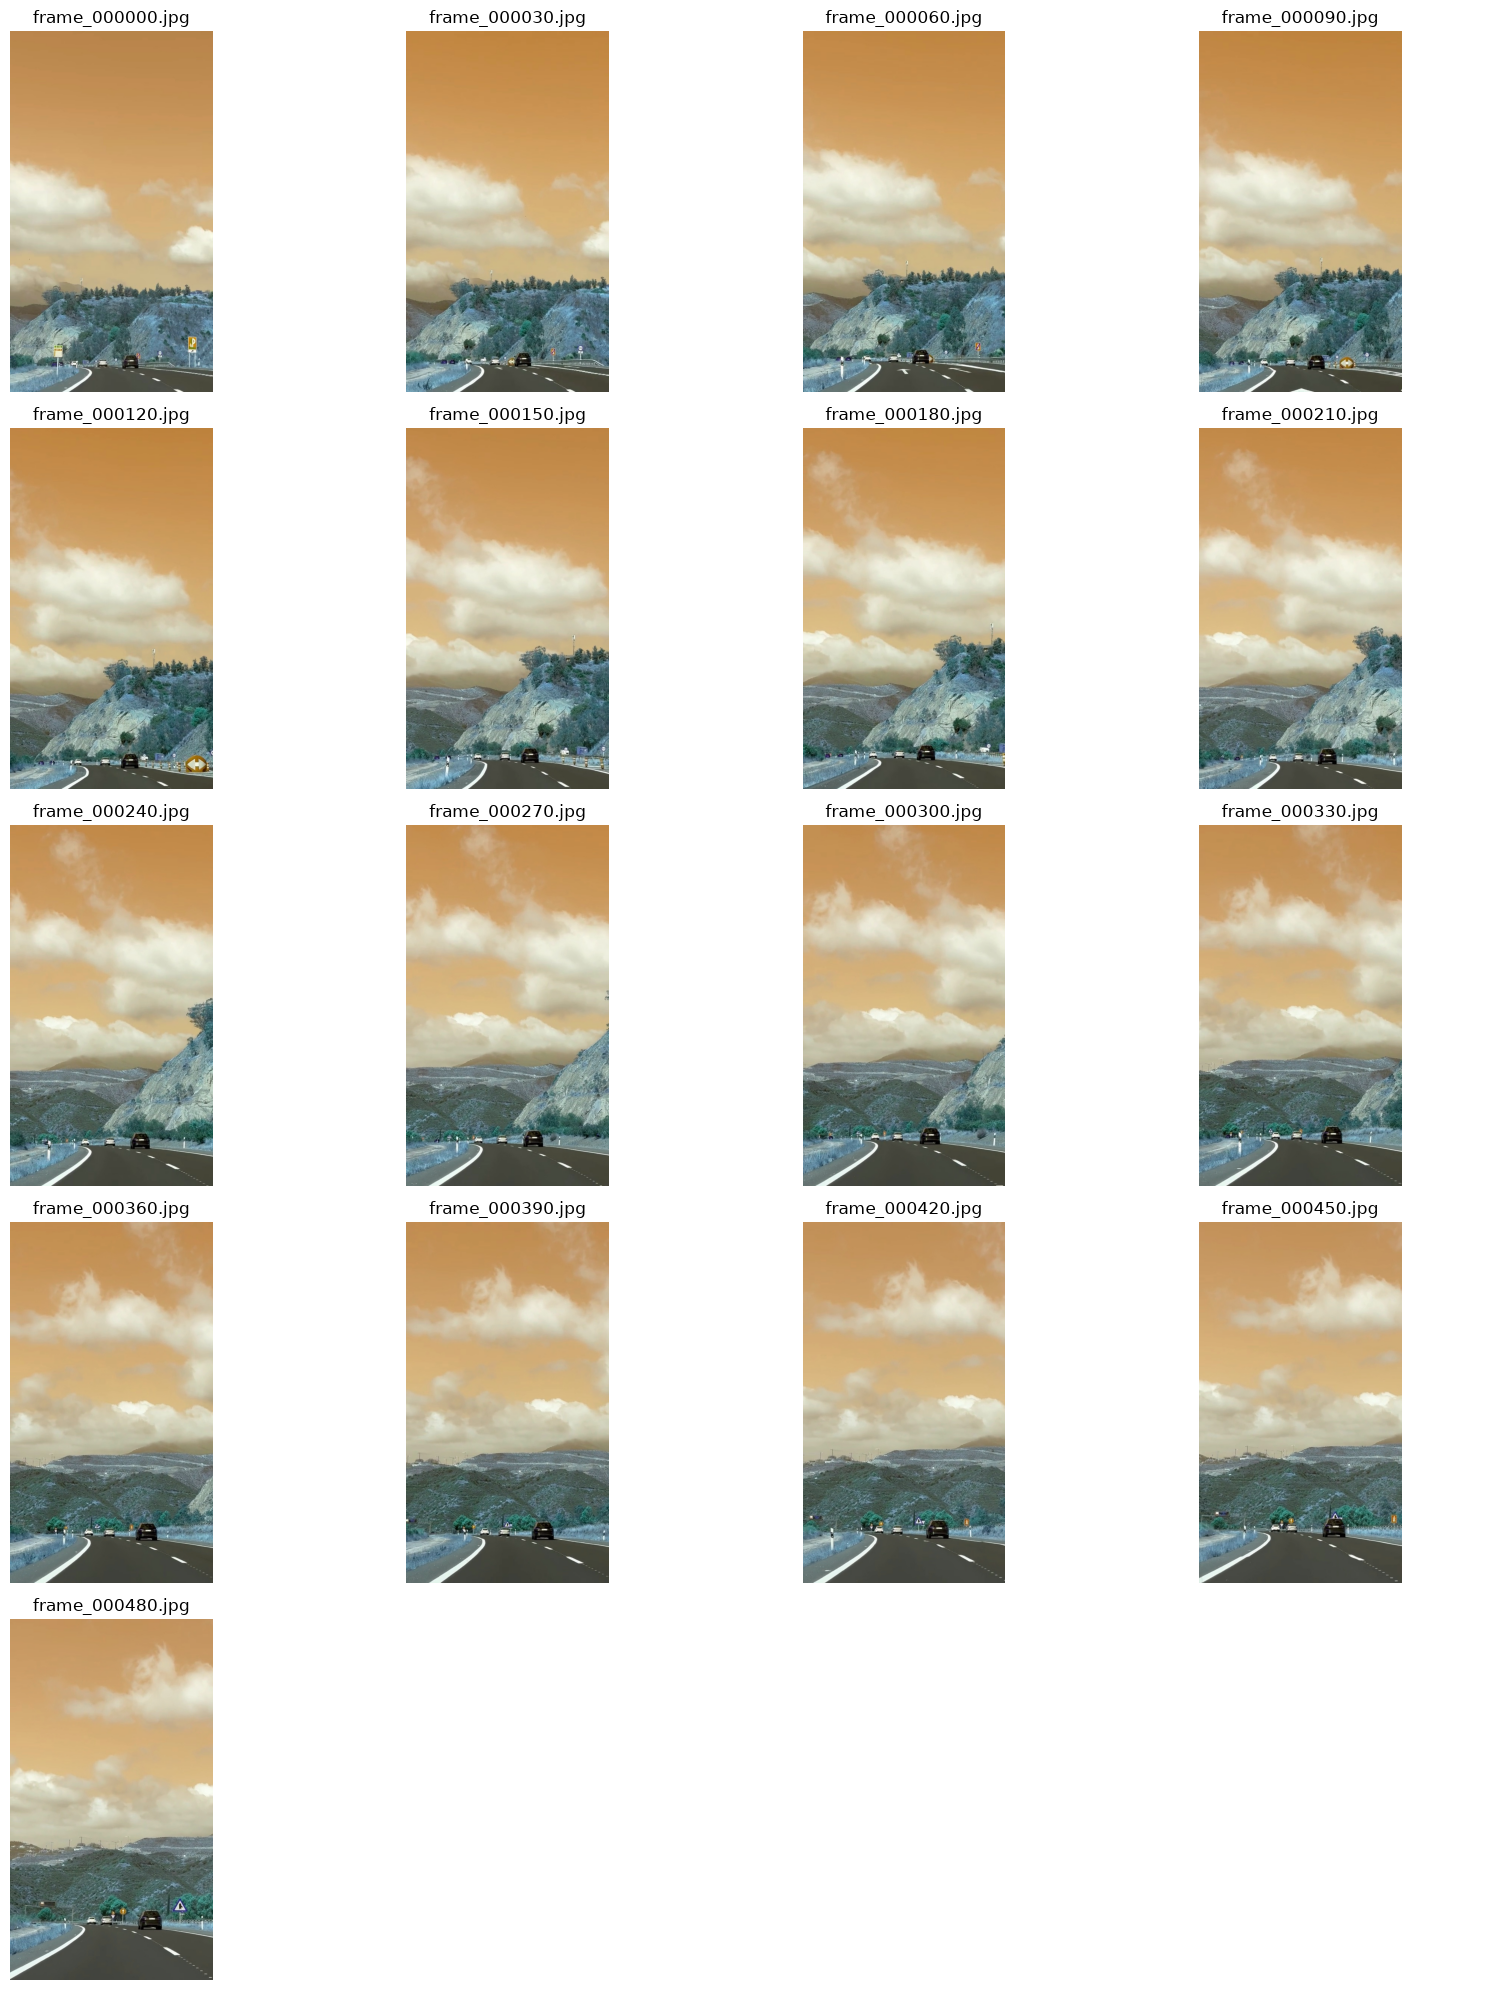

In [21]:
from pathlib import Path
import math
import cv2
import matplotlib.pyplot as plt

paths = sorted(Path("frames").glob("*.jpg"))

cols = 4                                   # har qatorda nechta
rows = math.ceil(len(paths) / cols)        # kerakli qatorlar soni

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()                      # 2D massivni oddiy ro'yxatga aylantiradi

for ax, p in zip(axes, paths):
    img = cv2.imread(str(p))
    if img is None:
        continue
    ax.imshow(img)
    # ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(p.name)
    ax.axis("off")

# Ortib qolgan bo'sh kataklarni yashirish
for ax in axes[len(paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

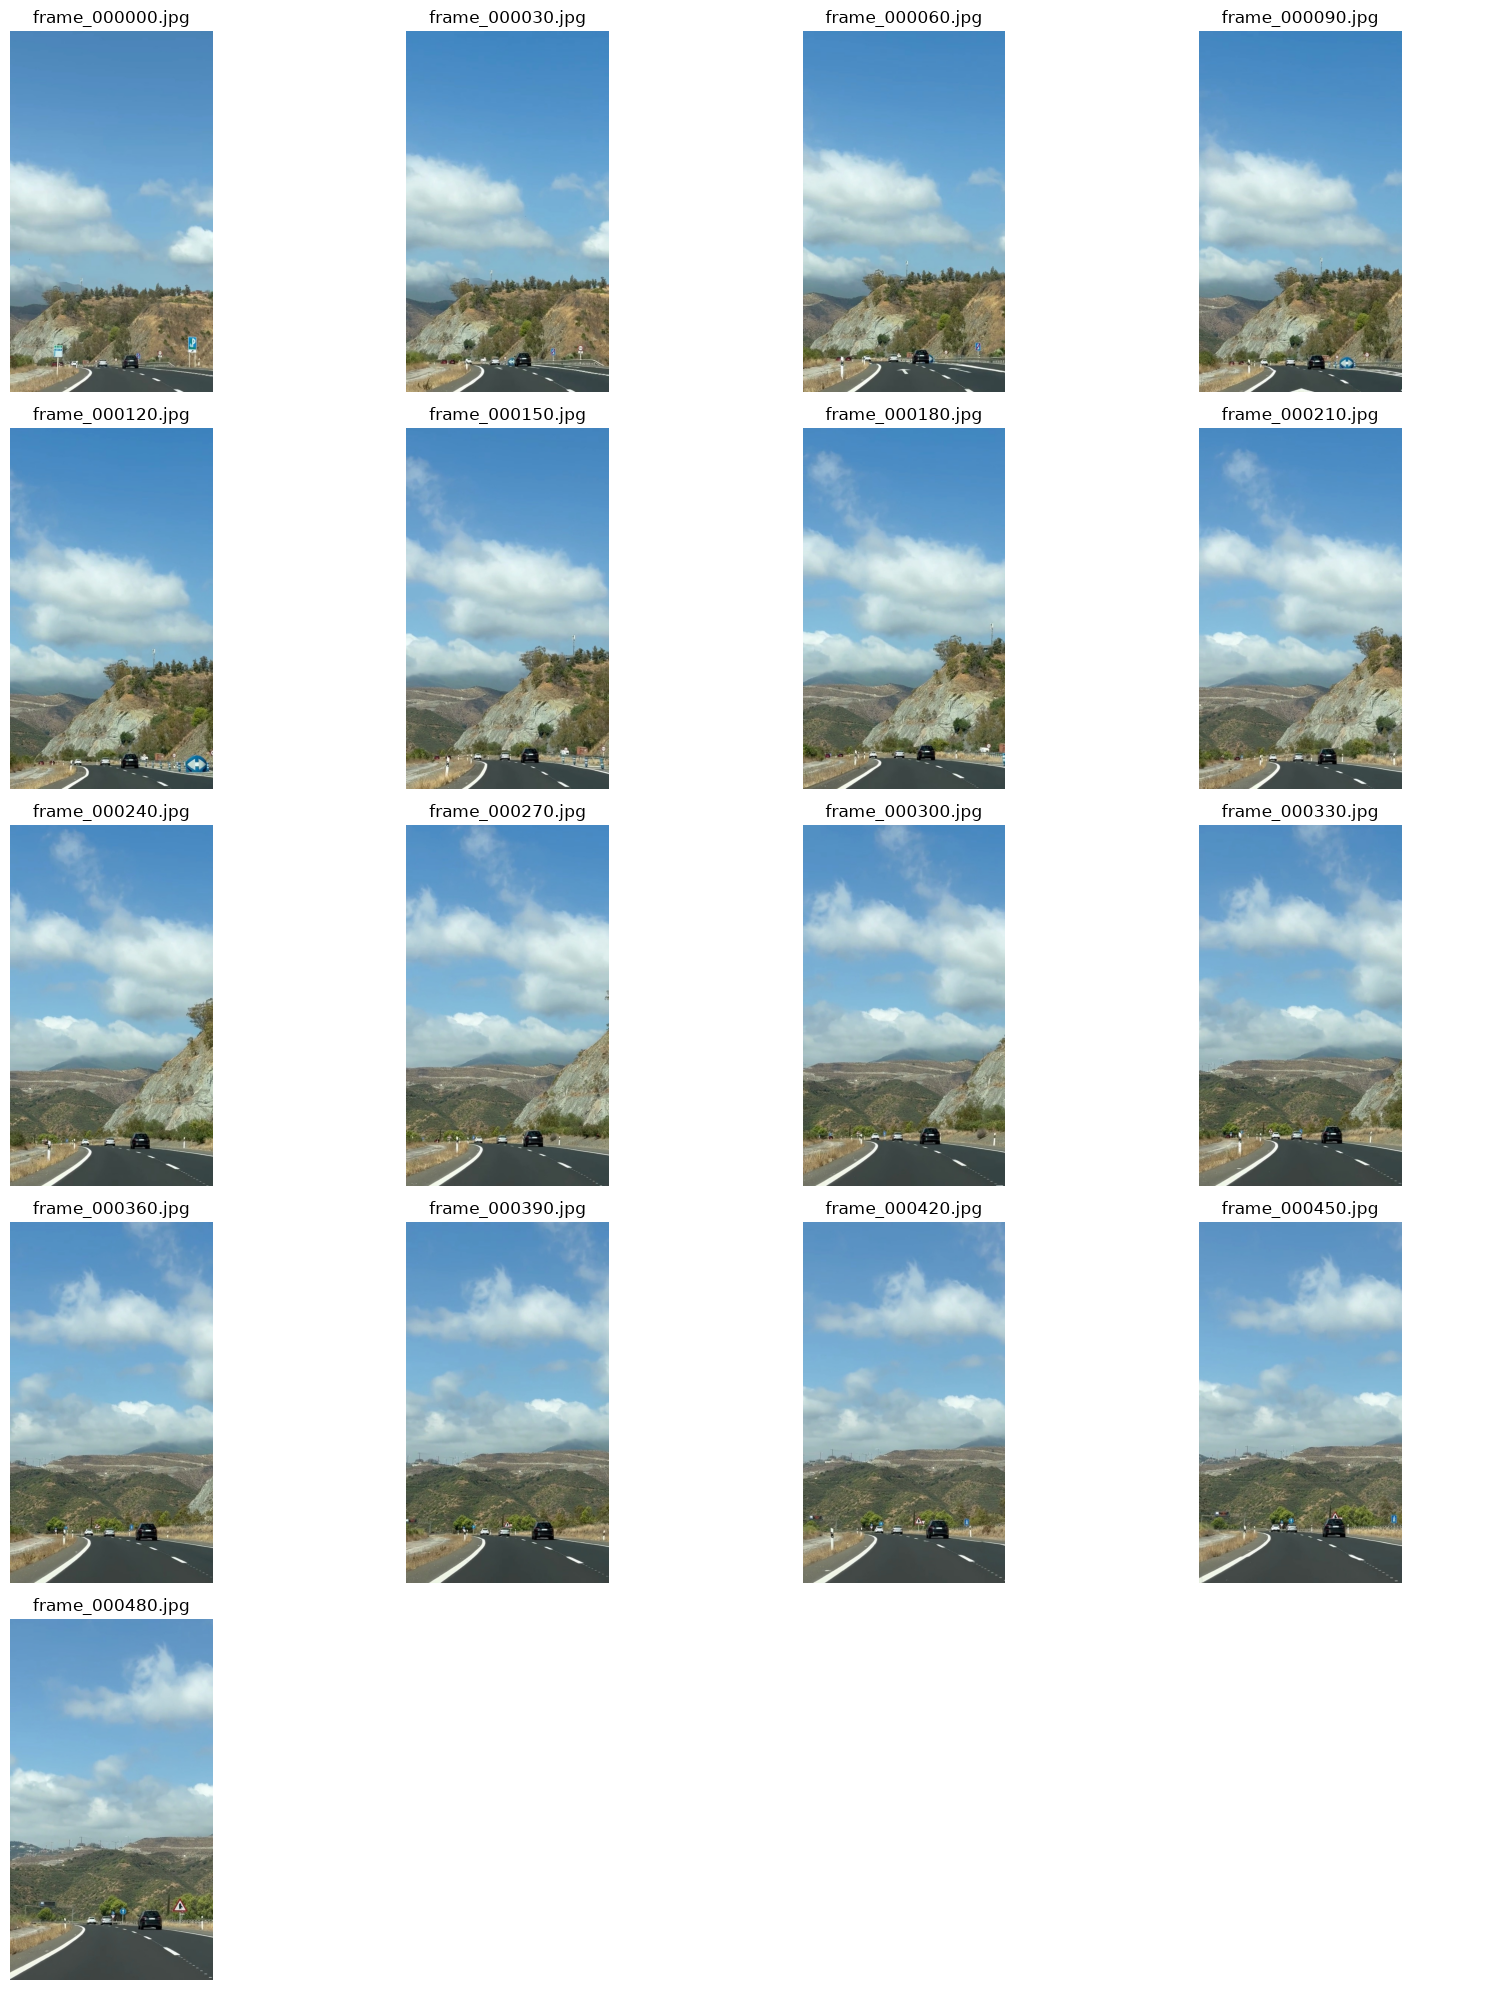

In [22]:
from pathlib import Path
import math
import cv2
import matplotlib.pyplot as plt

paths = sorted(Path("frames").glob("*.jpg"))

cols = 4                                   # har qatorda nechta
rows = math.ceil(len(paths) / cols)        # kerakli qatorlar soni

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()                      # 2D massivni oddiy ro'yxatga aylantiradi

for ax, p in zip(axes, paths):
    img = cv2.imread(str(p))
    if img is None:
        continue
    # ax.imshow(img)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(p.name)
    ax.axis("off")

# Ortib qolgan bo'sh kataklarni yashirish
for ax in axes[len(paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()